# GEOL 415 Lab 5 -- Prediction and linear regression

Welcome to Lab 5. This week you will create mathematical models that relate physical input variables to an observed response in the Earth system.

Specifically, you will:
- Load and filter data prior to performing linear regression
- Gain experience with the  Scikit Learn library to perform linear regression
- Analyze the model fit relative to observed data.

# 0 - Startup

Run the cell below to import the libraries necessary for this assignment. **Be sure to run this notebook using your geol415 conda env as well as your GEOL415 kernel!!!** 

In [1]:
import sys
print(sys.executable)

C:\Users\justi\anaconda3\envs\geol415\python.exe


### If the above cell does not return a path including `anaconda` or `miniconda3` followed by `envs/geol415`, you will need to properly activate the `geol415` conda environment before running the notebook. 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn import linear_model as lm
import os

## Modeling a relationship between two variables using Linear Regression

It is often useful to devise a mathematical expression to relate to environmental variables. This can be done to explore relationships between data. It can also be used to model values of a variable purely in terms of another. This may be useful if your dependent variable is difficult to obtain data for.

We will use **linear regression** to estimate the relationship between PM 2.5 pollutant concentrations and ambient air temperature derived from our favorite DTLA air monitoring site. 

## 1 -- Load data: EPA PM 2.5 and temp daily measurements and temperature

Measurements are reported in daily averages for PM mass (units: micrograms per cubic meter), and air temperature (units: Fahrenheit).


In [3]:
ddir = 'data/'
csv_path = os.path.join(ddir, r"C:\Users\justi\OneDrive\Documents\GEOL_415\Assignments\lab05\lab05\lab05\data\PM_Temp_LA.csv")
df = pd.read_csv(csv_path)
df

,date_local,mean_pm_mass,mean_temp_F
0,2025-01-01,32.807292,54.833333
1,2025-01-02,20.245833,60.541667
2,2025-01-03,26.500000,55.791667
3,2025-01-04,31.081944,55.708333
4,2025-01-05,11.705556,59.375000
...,...,...,...
358,2025-12-27,7.018750,53.875000
359,2025-12-28,7.683333,55.583333
360,2025-12-29,6.902778,57.958333
361,2025-12-30,5.573611,65.083333


## Q1. Plot Temperature and PM2.5 

Let's examine this relationship to see if it looks linear at all. We will do this by plotting PM2.5 (dependent variable) as a function of temperature (independent variable). 

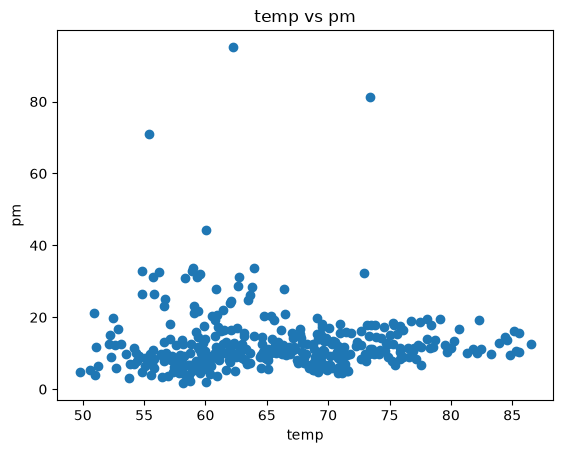

In [4]:
# get the proper columns for temp and pm and assign them to these easy-to-use variables
temp = df['mean_temp_F']
pm = df['mean_pm_mass']

# add proper labels!
plt.subplots()
plt.scatter(temp, pm)
plt.xlabel('temp')
plt.ylabel('pm')
plt.title('temp vs pm')

plt.show()

This is a line, for sure. However, we see there are some outliers in the data. While important, these will significantly skew a linear fit. Let us assume these are **very anomalous** (read: cheat) and try masking them out of our dataset.

# Q1.5 Use `np.percentile()` to remove PM values that are above the 90th percentile of the data set. 

HINT: `np.percentile()` takes 2 arguments (separated by a comma) as input in the parentheses: the array (or `pd.Series`) of data you are working with, and an integer that is the percentile you are interested in.

HINT 2: we want all PM data BELOW the 90th percentile mass value of the dataset.

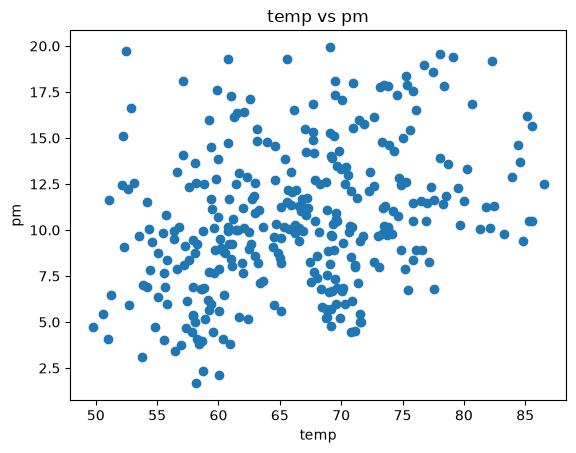

In [5]:
# remove outliers from the PM mass column. This returns a True/False array
percentile_90 = np.percentile(df['mean_pm_mass'], 90)
mask = df['mean_pm_mass'] < percentile_90 # what logical operator should be used??

# now use mask to filter the temp and pm arrays.
temp_masked = df['mean_temp_F'][mask]
pm_masked = df['mean_pm_mass'][mask]

#plot data here. Again, add labels and title.
plt.subplots()
plt.scatter(temp_masked, pm_masked)
plt.xlabel('temp')
plt.ylabel('pm')
plt.title('temp vs pm')

plt.show()

You should see a trend here. This seems worth performing linear regression on!

## 2 -- Linear regression essentials

Linear regression seeks to establish a numerical relationship between an dependent variable `y` and independent variable(s) `x`. Today, we'll be investigating the case where we have only **one** independent variable. In math, this looks like a linear function, i.e.:

$$y = \alpha + \beta x $$

Here, $y$ = PM 2.5 , $x$ = temperature, $\alpha$ is the y-intercept, ands $\beta$ is be the slope, or strength, of that relationship.

## Q2. Use Scikit Learn's `LinearRegression` (found within our `lm` that we imported) to get $\alpha$ and $\beta$.

There are lots of ways to get these, but sklearn is a nice library for this.

A nice thing about `LinearRegression` is it can perform multiple linear regression, i.e. regression with more than one X variable. This means `LinearRegression` requires that the X argument as a `pd.DataFrame` or a 2-D matrix object. In this case, we can't just use our temp array for X, but rather we need to do a quick conversion first.

In [6]:
x_data = pd.DataFrame(temp_masked)
y_data = pm_masked

#initialize a model object here
model = lm.LinearRegression()

# use the .fit() method to get a and b
model.fit(X = x_data, y= y_data)

print('alpha = {}, beta = {}'.format(model.intercept_, model.coef_[0]))

predicted_pm = model.intercept_ + model.coef_[0] * 0
print(predicted_pm)

alpha = 0.06712188060689606, beta = 0.15780843641996728
0.06712188060689606


**Quick check** Let's say we have a bizarrely cold day in LA, and the mean temperature is exactly 0 degrees F. Based on our mode, what would the predicted PM value be? HINT: Plug in alpha and beta into the linear function described above.

**ANSWER (1 sentence, possibly 1 word)**: The predicted PM value would be 0.067, as a temperature of 0 would remove any coeficient, leaving only the intercept remaining.

## Q3. Use the fit parameters to plot a line over the data

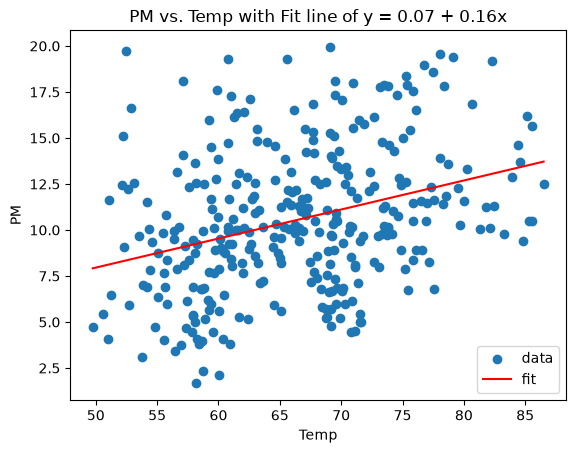

In [7]:
#First get a and b. Check the print statement above to see how to get them.
a = model.intercept_
b = model.coef_[0]

# np.linspace() gives uniform x-values. Don't touch!!!
x_points = np.linspace(x_data['mean_temp_F'].min(), x_data['mean_temp_F'].max(), 100)

# Multiply slope b by our x values to get predicted PM values.
line = a + b * x_points

plt.subplots()
# plot your original data points here as above.
plt.scatter(temp_masked, pm_masked, label='data')

# plot your fit line here. Think about which array to use for your x-values.
plt.plot(x_points, line, color='red', label='fit')
plt.xlabel('Temp')
plt.ylabel('PM')

# epic title 
plt.title(f'PM vs. Temp with Fit line of y = {a:.2f} + {b:.2f}x')

plt.legend()
plt.show()

This is a pretty good fit. We see the slope captures the overall trend of the point cloud, though the upper end of the line seems a little flat relative to our data. Let's see how we can **quantitatively** assess how good a job we did.

## 3 -- Assessing goodness of fit: strategies

Getting a line is not enough to draw many interesting conclusions from a regression line. It's often of interest to assess the goodness of fit. One way is to look at how the error of this fit looks

## Q4. Get the **coefficient of determination** (R-squared) for your fit line.

HINT: use the .score() method of your `model`.

The R-square tells us how much of the variance (standard deviation)^2 in Y (PM) is explainable by X (temperature). A perfect, amazing model would give us a R-squared value of 1. The worst model would give us 0.

In [8]:
r2 = model.score(X = x_data, y= pm_masked)
r2

0.10652116136980971

Depending on your idea of what is a good fit, this is...interesting. Our general fit captures the vibe of the data, but we see there is much to be desired here. This tells us we should look for better X values, perhaps incorporate more x variables, and so forth.

Let's keep going and see what else we can learn about our fit.

## Q5. Get the **residuals** between regression line and true data. 

Residuals are the difference between true vs. predicted PM2.5 at a particular temp value.

In linear regression, there is an assumption that a proper fit will produce residuals that satisfy the following:
- Residuals should be evenly dispersed across 0.
- Residuals should have an average value of 0.
- Residuals should be normally distributed (i.e. bell curve).

Systemic violations of these assumptions suggest that your model is not appropriate to describe the relationship between two (or more) variables.

Please compute residuals below, and plot them against your **predicted PM values**

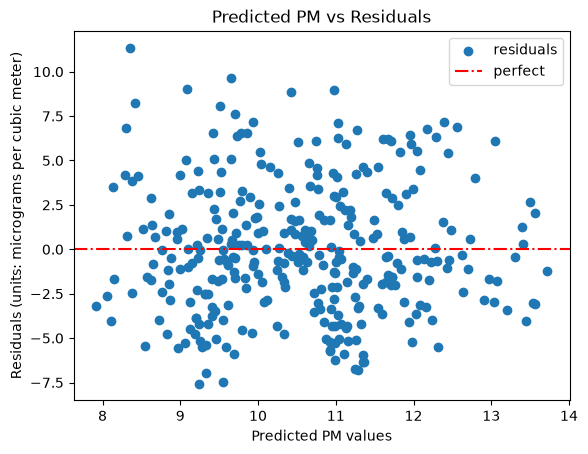

In [9]:
true = pm_masked
pred = a + b * temp_masked

res = true - pred

plt.scatter(pred, res, label='residuals')
plt.axhline(y=0, color='red', linestyle='-.', label='perfect')
plt.title('Predicted PM vs Residuals')
plt.xlabel('Predicted PM values')
plt.ylabel('Residuals (units: micrograms per cubic meter)')
plt.legend()
plt.show()

**Quick check:** How are these residuals distributed about 0? What is the amplitude of these residuals (i.e. how far away are the largest residuals from 0)? 
These residuals are distributed equally around the 0 mark. The amplitude of these residuals are ~-7.5 and ~12

## Q6. Get the mean of the residuals computed above. 

What does this value tell you about our regression model?

In [10]:
mean_res = np.mean(res)
print(f'Mean of residuals: {mean_res:.5f}')

Mean of residuals: 0.00000


# Q7. Plot a histogram of the residuals.

Try playing around with the number of bins. What does this do to the shape of the histogram? What might that tell you about visualizing data in general?

**ANSWER**: The larger the number of bins, the smaller the frequency will be as fewer datapoints fit within the decreased size of each bin. This tells us that visualizing data is heavily reliant on how we sort the data we have. 

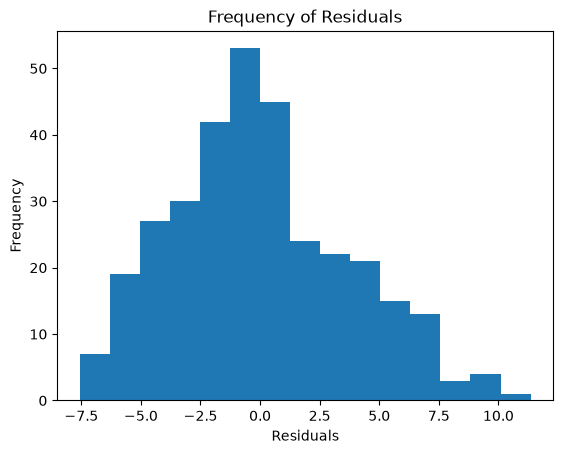

In [11]:
plt.hist(res, bins=15)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Frequency of Residuals');

## Q7. Compute the skew of the residuals. 

In [12]:
from scipy.stats import skew

In [13]:
print(f'Skewness of residuals: {skew(res):.5f}')

Skewness of residuals: 0.40345


**Quick check:** The skew of a normal distribution is 0. Let's say a distribution is severely skewed outside of +/- 1.0. What does your answer tell you about our residual assumption?

**ANSWER (1 sentence)**: The residual assumption of the data shows a moderately skewed distribution as the skew falls at 0.40.

## Mini-Evals (please fill out!!!)

1. Please rate 1-5 how this lab was for you. 1 := this was too difficult, 5 := I could do this in my sleep.

*Answer*: 3.5

2. What is something you wished I covered in this lab? 

*Answer*: I'm not sure

# Lab submission

Phew! That's quite enough of looking at our model residuals. I hope you gain a few new tools for analyzing the validity of your linear fits going forward in this class.

Please `Restart` and `Run All` on this notebook and submit this lab when you are done!